In [92]:
import pandas as pd
import numpy as np

In [93]:
df = pd.read_csv("../Snowflake Notebooks Package/data/data_join.csv")
df.head(5)

,LATITUDE,LONGITUDE,DATE,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS,PET,NIR,GREEN,SWIR16,SWIR22,NDMI,MNDWI
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


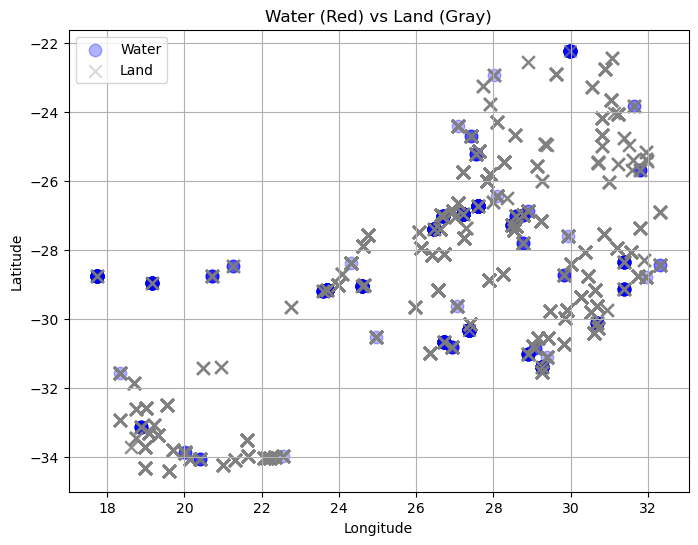

In [94]:
import matplotlib.pyplot as plt

df["water"] = df["MNDWI"] > 0

plt.figure(figsize=(8,6))

water = df[df["water"] == True]
plt.scatter(
    water["LONGITUDE"],
    water["LATITUDE"],
    c="blue",
    marker='o',
    s=80,
    alpha=0.3,
    label="Water"
)

land = df[df["water"] == False]
plt.scatter(
    land["LONGITUDE"],
    land["LATITUDE"],
    c="gray",
    marker='x',
    s=80,
    alpha=0.3,
    label="Land"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Water (Red) vs Land (Gray)")
plt.legend()
plt.grid()
plt.show()

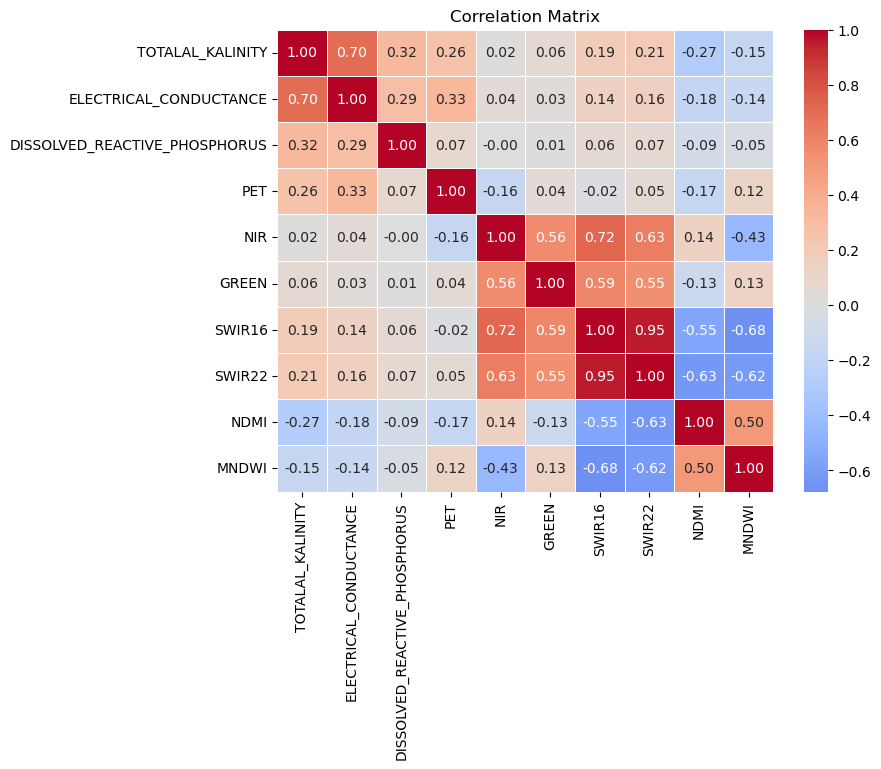

In [95]:
import seaborn as sns

corr_df = df[["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS", "PET", "NIR", "GREEN", "SWIR16", "SWIR22", "NDMI", "MNDWI"]].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix")
plt.show()  

In [ ]:
#Feature engineering
df["water_moisture_index"] = df["NDMI"] * df["MNDWI"]
df["evaporation_stress"] = df["PET"] / (df["NDMI"] + 1e-6)
df["SWIR_ratio"] = df["SWIR16"] / (df["SWIR22"] + 1e-6)
df["SWIR_diff"] = df["SWIR16"] - df["SWIR22"]
df["is_water"] = df["MNDWI"] > 0

# Weather feature
df["DATE"] = pd.to_datetime(df["DATE"], format='%d-%m-%Y')
df["month"] = df["DATE"].dt.month
df["year"] = df["DATE"].dt.year
df["dayofyear"] = df["DATE"].dt.dayofyear

# Date feature
df["month_sin"] = np.sin(2 * np.pi * df["month"]/12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]/12)
df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"]/365)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"]/365)

# log transform (skewed target)
df["DRP_log"] = np.log1p(df["DISSOLVED_REACTIVE_PHOSPHORUS"])
df["TOTALAL_log"] = np.log1p(df["TOTALAL_KALINITY"])
df["EC_log"] = np.log1p(df["ELECTRICAL_CONDUCTANCE"])

In [115]:
df.columns

Index(['LATITUDE', 'LONGITUDE', 'DATE', 'TOTALAL_KALINITY',
       'ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS', 'PET', 'NIR',
       'GREEN', 'SWIR16', 'SWIR22', 'NDMI', 'MNDWI', 'water',
       'water_moisture_index', 'evaporation_stress', 'SWIR_ratio', 'is_water',
       'month', 'year', 'dayofyear', 'DRP_log', 'SWIR_diff', 'month_sin',
       'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'TOTALAL_log', 'EC_log'],
      dtype='str')

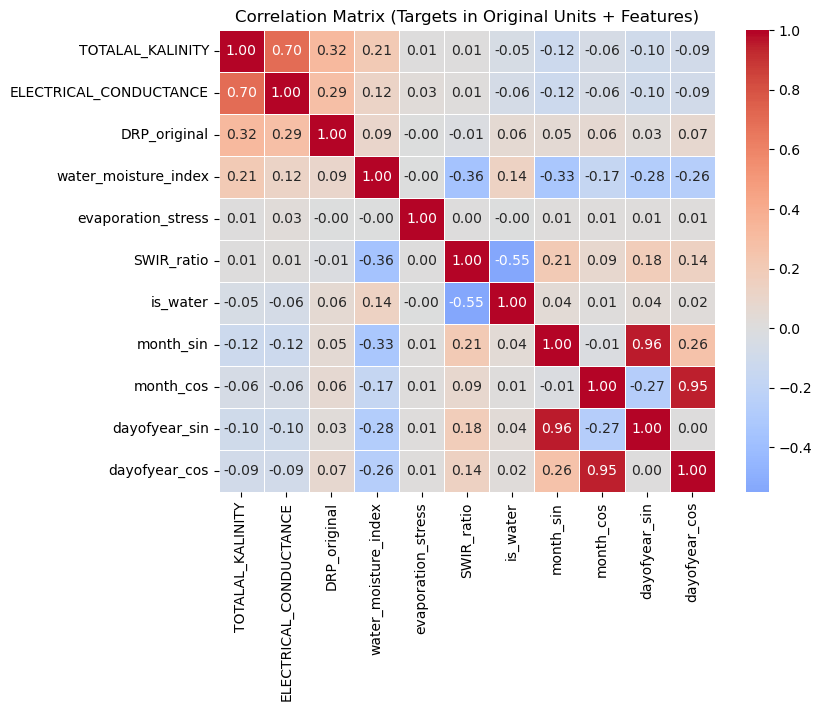

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df["DRP_original"] = np.expm1(df["DRP_log"])

corr_df = df[[ 
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE', 
    'DRP_original',               
    'water_moisture_index', 
    'evaporation_stress', 
    'SWIR_ratio', 
    'is_water',
    'month_sin', 'month_cos',    
    'dayofyear_sin', 'dayofyear_cos'
]].dropna()

corr_matrix_2 = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_2, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix (Targets in Original Units + Features)")
plt.show()

In [125]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

targets = ["TOTALAL_log", "EC_log", "DRP_log"] 
original_target_map = {
    "TOTALAL_log": "TOTALAL_KALINITY",
    "EC_log": "ELECTRICAL_CONDUCTANCE",
    "DRP_log": "DISSOLVED_REACTIVE_PHOSPHORUS"
}

df = df.sort_values("DATE").reset_index(drop=True)
X = df.drop(columns=targets + ["DATE", "LATITUDE", "LONGITUDE"]) 
y_dict = {t: df[t].values for t in targets}

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
avg_rmse_dict = {}

for target in targets:
    y = y_dict[target]
    rmse_list = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = LGBMRegressor(
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                __import__('lightgbm').early_stopping(50),
                __import__('lightgbm').log_evaluation(period=0)
            ]
        )

        last_model = model
        last_X_val, last_y_val = X_val, y_val

        y_pred_log = model.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_val)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        rmse_list.append(rmse)

    avg_rmse = np.mean(rmse_list)
    avg_rmse_dict[target] = avg_rmse

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4118
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 23
[LightGBM] [Info] Start training from score 4.479742
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l2: 0.00227514
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4337
[LightGBM] [Info] Number of data points in the train set: 3107, number of used features: 24
[LightGBM] [Info] Start training from score 4.513220
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1991]	valid_0's l2: 0.00157996
[LightGBM] [Info] Auto-choosing col-

In [126]:
df[['TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS']].describe()

,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS
count,9319.000000,9319.000000,9319.000000
mean,119.108208,485.004146,43.525338
std,74.692591,341.937736,50.980194
min,4.800000,15.120000,5.000000
25%,55.811000,207.050000,10.000000
50%,113.300000,402.000000,20.000000
75%,170.230000,693.000000,48.000000
max,361.676000,1506.000000,195.000000


In [127]:
print("\n=== Average RMSE for each target ===")
for target, rmse in avg_rmse_dict.items():
    original_target = original_target_map[target]
    mean_val = df[original_target].mean()
    ratio = rmse / mean_val

    print(f"{original_target}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  RMSE/Mean: {ratio:.2%}\n")


=== Average RMSE for each target ===
TOTALAL_KALINITY
  RMSE: 3.9790
  Mean: 119.1082
  RMSE/Mean: 3.34%

ELECTRICAL_CONDUCTANCE
  RMSE: 17.4461
  Mean: 485.0041
  RMSE/Mean: 3.60%

DISSOLVED_REACTIVE_PHOSPHORUS
  RMSE: 1.1698
  Mean: 43.5253
  RMSE/Mean: 2.69%



C:\Users\woobi\AppData\Local\Temp\ipykernel_23916\3152276637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")


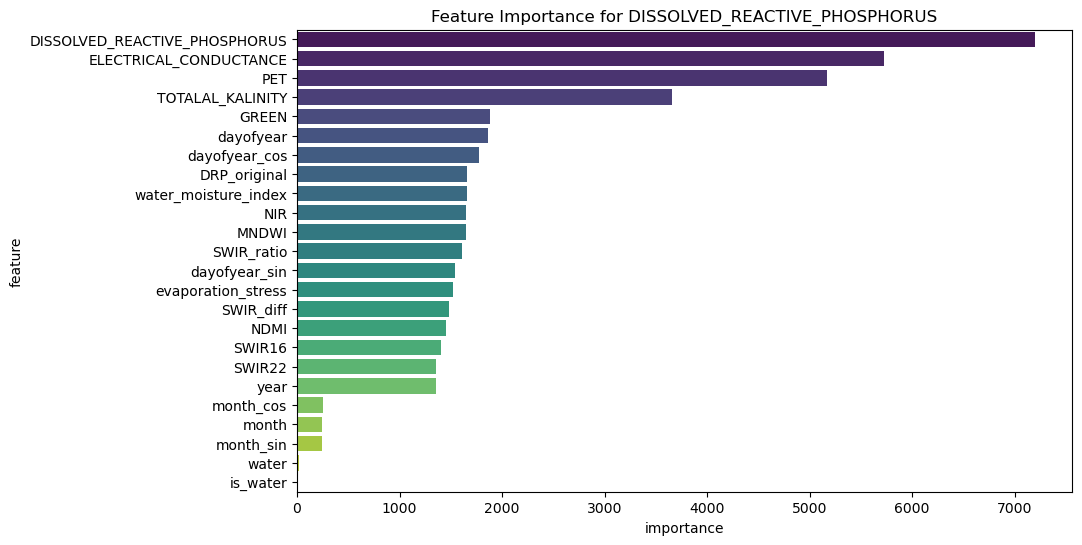

In [128]:
importances = last_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df, x="importance", y="feature", palette="viridis")
plt.title(f"Feature Importance for {original_target_map[target]}")
plt.show()

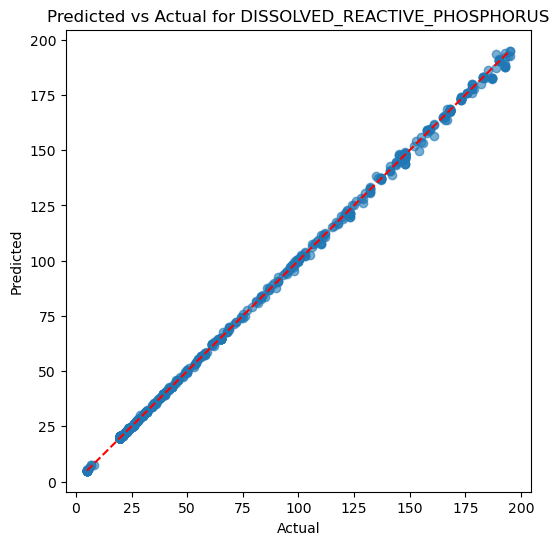

In [129]:
y_pred_log = last_model.predict(last_X_val)

if target == "DRP_log":
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(last_y_val)
else:
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(last_y_val)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual for {original_target_map[target]}")
plt.show()

In [131]:
# =========================
# 1️⃣ Data Leakage & Fold Check
# =========================

issues_found = False

# --- Feature vs Target  ---
print("=== Feature vs Target Columns Check ===")
for target in ["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS"]:
    if target in X.columns:
        print(f"⚠️ issues found: {target} is in feature (likely data leakage)")
        issues_found = True
    else:
        print(f"{target} not in features ✅")
print()

# --- TimeSeriesSplit index  ---
print("=== TimeSeriesSplit index check ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    overlap = np.intersect1d(train_idx, val_idx)
    if len(overlap) > 0:
        print(f"⚠️ Fold {fold}: train/val index overlap ({len(overlap)}) → likely data leakage")
        issues_found = True
    else:
        print(f"Fold {fold}: No overlap ✅")
print()

# --- Fold별 RMSE ---
print("=== Fold-wise RMSE check ===")
for target in ["TOTALAL_log", "EC_log", "DRP_log"]:
    y = y_dict[target]
    rmse_list = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                __import__('lightgbm').early_stopping(50),
                __import__('lightgbm').log_evaluation(period=0)
            ]
        )

        y_pred_log = model.predict(X_val)
        if target == "DRP_log":
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_val)
        else:
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_val)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        rmse_list.append(rmse)

    avg_rmse = np.mean(rmse_list)
    mean_val = np.mean(y_true)
    ratio = avg_rmse / mean_val
    print(f"{target}: Avg RMSE={avg_rmse:.2f}, Mean={mean_val:.2f}, RMSE/Mean={ratio:.2%}")

    if ratio < 0.05:  
        print(f"⚠️ Warning: RMSE/Mean is too low → likely data leakage")
        issues_found = True
print()

if not issues_found:
    print("✅ all checks passed! No obvious data leakage or fold issues detected.")

=== Feature vs Target Columns Check ===
⚠️ issues found: TOTALAL_KALINITY is in feature (likely data leakage)
⚠️ issues found: ELECTRICAL_CONDUCTANCE is in feature (likely data leakage)
⚠️ issues found: DISSOLVED_REACTIVE_PHOSPHORUS is in feature (likely data leakage)

=== TimeSeriesSplit index check ===
Fold 1: No overlap ✅
Fold 2: No overlap ✅
Fold 3: No overlap ✅
Fold 4: No overlap ✅
Fold 5: No overlap ✅

=== Fold-wise RMSE check ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4118
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 23
[LightGBM] [Info] Start training from score 4.479742
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[132]	valid_0's l2: 0.000136065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.00

In [133]:

# =====================
# 1️⃣ 타겟 설정 & feature 재정의
# =====================
targets = [
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS'
]

df = df.sort_values("DATE").reset_index(drop=True)

# DRP log 변환 추가
df["DRP_log"] = np.log1p(df["DISSOLVED_REACTIVE_PHOSPHORUS"])

# feature에서 타겟 제거! → 데이터 누수 방지
X = df.drop(columns=targets + ['DATE'])
y_dict = {
    'TOTALAL_KALINITY': df['TOTALAL_KALINITY'].values,
    'ELECTRICAL_CONDUCTANCE': df['ELECTRICAL_CONDUCTANCE'].values,
    'DRP_log': df['DRP_log'].values
}

# =====================
# 2️⃣ TimeSeriesSplit 설정
# =====================
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# =====================
# 3️⃣ 모델 학습 + fold별 RMSE 계산
# =====================
avg_rmse_dict = {}

for target in y_dict.keys():
    y = y_dict[target]
    rmse_list = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                __import__('lightgbm').early_stopping(50),
                __import__('lightgbm').log_evaluation(period=0)
            ]
        )

        y_pred = model.predict(X_val)

        # DRP_log는 원래 단위로 변환
        if target == "DRP_log":
            y_pred = np.expm1(y_pred)
            y_val = np.expm1(y_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)

    avg_rmse = np.mean(rmse_list)
    avg_rmse_dict[target] = avg_rmse

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4397
[LightGBM] [Info] Number of data points in the train set: 1554, number of used features: 25
[LightGBM] [Info] Start training from score 117.367106
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[116]	valid_0's l2: 5.04471
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4640
[LightGBM] [Info] Number of data points in the train set: 3107, number of used features: 26
[LightGBM] [Info] Start training from score 120.884537
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[199]	valid_0's l2: 0.518988
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ove

In [134]:
print("\n=== RMSE / Mean Ratio (누수 제거 후) ===")
for target, rmse in avg_rmse_dict.items():
    mean_val = df[target].mean()
    ratio = rmse / mean_val
    print(f"{target}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  RMSE/Mean: {ratio:.2%}\n")


=== RMSE / Mean Ratio (누수 제거 후) ===
TOTALAL_KALINITY
  RMSE: 1.0467
  Mean: 119.1082
  RMSE/Mean: 0.88%

ELECTRICAL_CONDUCTANCE
  RMSE: 3.6941
  Mean: 485.0041
  RMSE/Mean: 0.76%

DRP_log
  RMSE: 0.4330
  Mean: 3.2990
  RMSE/Mean: 13.13%



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4819
[LightGBM] [Info] Number of data points in the train set: 9319, number of used features: 26
[LightGBM] [Info] Start training from score 119.108208


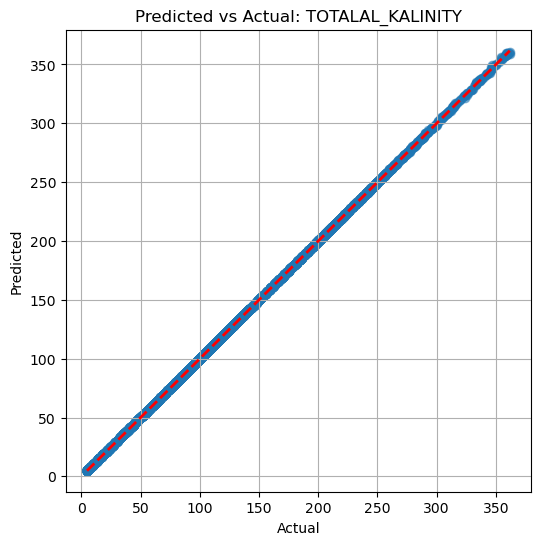

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4819
[LightGBM] [Info] Number of data points in the train set: 9319, number of used features: 26
[LightGBM] [Info] Start training from score 485.004146


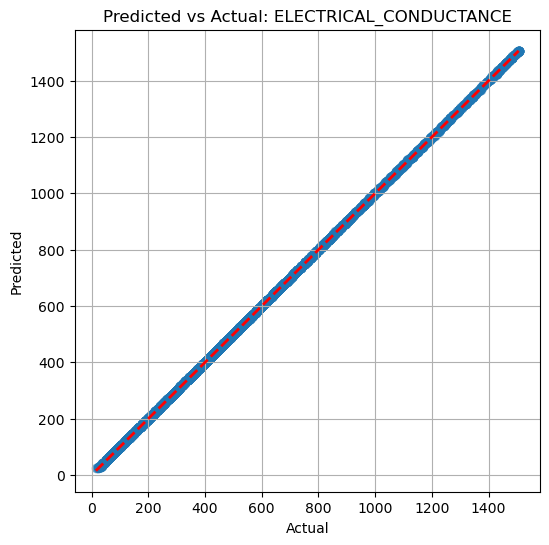

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4819
[LightGBM] [Info] Number of data points in the train set: 9319, number of used features: 26
[LightGBM] [Info] Start training from score 43.525338


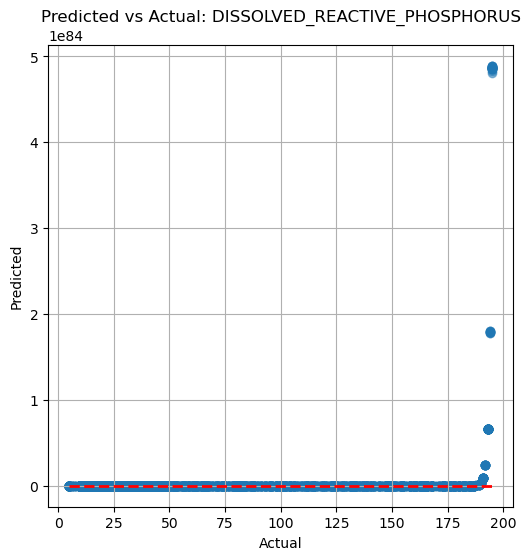

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# 예측값과 실제값 비교용
for target in ['TOTALAL_KALINITY', 'ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS']:
    
    # 모델 재학습 없이 간단히 마지막 fold 기준 예시
    y_true = df[target].values
    X_feat = df.drop(columns=targets + ['DATE'])
    
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42
    )
    model.fit(X_feat, y_true)
    y_pred = model.predict(X_feat)
    
    # DRP_log 사용했으면 역변환
    if target == 'DISSOLVED_REACTIVE_PHOSPHORUS' and 'DRP_log' in df.columns:
        y_pred = np.expm1(y_pred)
        y_true = df['DISSOLVED_REACTIVE_PHOSPHORUS'].values

    # Scatter plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Predicted vs Actual: {target}')
    plt.grid(True)
    plt.show()

In [136]:
targets = [
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS'
]

# 1️⃣ Feature vs Target Check
feature_cols = df.drop(columns=targets + ['DATE']).columns
print("=== Feature vs Target Columns Check ===")
for t in targets:
    if t in feature_cols:
        print(f"⚠️ 문제: {t}가 feature에 포함됨 (데이터 누수 가능성)")
    else:
        print(f"{t}: 문제 없음 ✅")

# 2️⃣ TimeSeriesSplit index 겹침 체크
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print("\n=== TimeSeriesSplit index check ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(df)):
    overlap = np.intersect1d(train_idx, val_idx)
    if len(overlap) > 0:
        print(f"Fold {fold+1}: 겹침 ⚠️")
    else:
        print(f"Fold {fold+1}: No overlap ✅")

=== Feature vs Target Columns Check ===
TOTALAL_KALINITY: 문제 없음 ✅
ELECTRICAL_CONDUCTANCE: 문제 없음 ✅
DISSOLVED_REACTIVE_PHOSPHORUS: 문제 없음 ✅

=== TimeSeriesSplit index check ===
Fold 1: No overlap ✅
Fold 2: No overlap ✅
Fold 3: No overlap ✅
Fold 4: No overlap ✅
Fold 5: No overlap ✅
